# Description des variables quantitatives — corpus RapFr

Ce notebook constitue la première étape de l'analyse du corpus de textes de rap français contenu dans `RapFr.csv`.

> **Statut : premier jet.** Ce notebook pose une base de description générale du corpus (statistiques, distributions, évolution temporelle). Il n'est volontairement pas définitif : le travail demandé aux étudiants est d'affiner ce script (choix des variables clés, filtres, granularité temporelle, mise en forme des graphiques...) et surtout de **mettre en valeur des faits remarquables** repérés dans les données, en les commentant.
>
> Ce projet s'inscrit dans le cadre du cours d'application des méthodes de data science et d'IA à l'analyse de corpus volumineux, du parcours **CPES Sciences des données, Arts et Cultures (DAC)**, porté par l'[Université PSL](https://psl.eu/) et le [Lycée Louis-le-Grand](https://www.louislegrand.fr/) ([page du parcours](https://psl.eu/formation/cpes-psl-louis-le-grand)), avec l'appui de l'[Institut ACSS-PSL](https://acss-dig.psl.eu/).

**Source des données :** `RapFr.csv` correspond au corpus **LRFAF** (37 307 chansons de rap français, genius.com croisé avec Wikipédia/Wikidata), constitué par Benoît de Courson — [jeu de données sur Hugging Face](https://huggingface.co/datasets/regicid/LRFAF) et [article associé](https://www.researchgate.net/publication/379061284_LRFAF_une_exploration_numerique_du_rap_francais_depuis_les_annees_1990).

**Objectifs :**
- Décrire les variables quantitatives du corpus (statistiques descriptives, distributions).
- Étudier l'évolution des moyennes de ces variables au cours du temps, à l'échelle de l'année.

**Plan :**
1. Chargement des bibliothèques et configuration
2. Lecture de `RapFr.csv` et contrôle initial
3. Préparation des variables quantitatives et de l'échelle annuelle
4. Tableau descriptif global des variables quantitatives
5. Distributions univariées (histogrammes, densités, boxplots)
6. Distributions par année (facettes / sous-échantillons annuels)
7. Évolution des moyennes annuelles par variable
8. Visualisations comparatives des tendances (multi-courbes, lissage)
9. Synthèse tabulaire exportable (moyennes annuelles et dispersion)

## 1. Chargement des bibliothèques et configuration

On importe les bibliothèques nécessaires à la manipulation des données (`pandas`, `numpy`) et à la visualisation (`matplotlib`, `seaborn`), puis on fixe le style graphique et les options d'affichage des tableaux.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Style graphique et options d'affichage
sns.set_theme(style="whitegrid", palette="viridis")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["figure.dpi"] = 100

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 150)
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")

# Organisation du projet : scripts à la racine, figures dans images/, tables dans result/
IMAGES_DIR = Path("images")
RESULT_DIR = Path("result")
IMAGES_DIR.mkdir(exist_ok=True)
RESULT_DIR.mkdir(exist_ok=True)

## 2. Lecture de `RapFr.csv` et contrôle initial

On charge le fichier CSV et on inspecte ses dimensions, un aperçu des premières lignes, les noms de colonnes et leurs types.

In [2]:
df = pd.read_csv("RapFr.csv")

print(f"Dimensions du corpus : {df.shape[0]} lignes x {df.shape[1]} colonnes")
display(df.head(3))

print("\nColonnes et types :")
print(df.dtypes)

Dimensions du corpus : 37307 lignes x 33 colonnes


,artist,title,year,lyrics,pageviews,contributors,url,topic,topic_clean,ranking,n_je,n_profanity,n_verlan,n_french_words,means_word_length,n_unique_words,n_words,pageviews_corrected,n_non_french_words,n_argot,n_onomatopee,n_negative,n_positive,birthdate_artist,age_artist,pageview_mean,pageviews_2,n_sexe,hate,sexism,n_lines,sentiment2,born_in_france
0,Dee Nasty,Paname City Rappin,"1,984.00","\nPaname city rappin', c'est le Paname city ra...",0,9,https://genius.com/Dee-nasty-paname-city-rappi...,bt-7,Rap coquin,"3,466.00",20,1,5,773,3.54,246,813,3.64,40,8,0,19,29,NaN,NaN,0.00,NaN,1,0.22,0.11,87,-0.21,NaN
1,IAM,IAM concept,"1,989.00","\nEn force, Asiatic attaque en rimes\nDéclaran...",0,7,https://genius.com/Iam-iam-concept-lyrics,bt-6,Egotrip/Méta-rap,"1,860.00",8,1,5,525,4.41,339,577,3.16,52,4,0,11,10,"1,966.00",23.00,0.00,NaN,0,0.29,0.11,81,-0.02,0.86
2,IAM,Total Kheops,"1,989.00","\nQuand ce sera la fin d'la musique, tu tirera...",0,4,https://genius.com/Iam-total-kheops-lyrics,bt-6,Egotrip/Méta-rap,192.00,30,7,8,717,3.88,426,790,3.16,73,25,0,34,21,"1,966.00",23.00,0.00,NaN,0,0.43,0.33,85,-0.36,0.86



Colonnes et types :
artist                     str
title                      str
year                   float64
lyrics                     str
pageviews                int64
contributors             int64
url                        str
topic                      str
topic_clean                str
ranking                float64
n_je                     int64
n_profanity              int64
n_verlan                 int64
n_french_words           int64
means_word_length      float64
n_unique_words           int64
n_words                  int64
pageviews_corrected    float64
n_non_french_words       int64
n_argot                  int64
n_onomatopee             int64
n_negative               int64
n_positive               int64
birthdate_artist       float64
age_artist             float64
pageview_mean          float64
pageviews_2            float64
n_sexe                   int64
hate                   float64
sexism                 float64
n_lines                  int64
sentiment2        

### 2.1 Valeurs manquantes

Vérification du nombre et de la proportion de valeurs manquantes par colonne, afin d'anticiper leur traitement dans les analyses suivantes.

In [3]:
missing = pd.DataFrame({
    "n_manquants": df.isna().sum(),
    "pct_manquants": (df.isna().mean() * 100).round(2),
}).sort_values("pct_manquants", ascending=False)

display(missing[missing["n_manquants"] > 0])

,n_manquants,pct_manquants
age_artist,23243,62.30
birthdate_artist,22031,59.05
born_in_france,21227,56.90
ranking,6638,17.79
pageviews_corrected,3611,9.68
year,3611,9.68
hate,87,0.23
sexism,87,0.23
sentiment2,87,0.23
means_word_length,32,0.09


## 3. Préparation des variables quantitatives et de l'échelle annuelle

### 3.1 Identification des variables quantitatives

On sélectionne automatiquement les colonnes de type numérique, en excluant les identifiants qui ne sont pas des variables d'intérêt statistique (ex. `year`, traité séparément comme échelle temporelle).

In [4]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
numeric_cols = [c for c in numeric_cols if c != "year"]

print(f"{len(numeric_cols)} variables quantitatives identifiées :")
print(numeric_cols)

26 variables quantitatives identifiées :
['pageviews', 'contributors', 'ranking', 'n_je', 'n_profanity', 'n_verlan', 'n_french_words', 'means_word_length', 'n_unique_words', 'n_words', 'pageviews_corrected', 'n_non_french_words', 'n_argot', 'n_onomatopee', 'n_negative', 'n_positive', 'birthdate_artist', 'age_artist', 'pageview_mean', 'pageviews_2', 'n_sexe', 'hate', 'sexism', 'n_lines', 'sentiment2', 'born_in_france']


### 3.2 Normalisation de l'échelle annuelle

On nettoie la variable `year` : suppression des valeurs manquantes ou hors plage plausible, conversion en entier, puis tri. Un DataFrame d'analyse `df_analysis` est créé pour la suite du notebook.

In [5]:
CURRENT_YEAR = 2026
MIN_PLAUSIBLE_YEAR = 1980

df_analysis = df.copy()
df_analysis = df_analysis.dropna(subset=["year"])
df_analysis = df_analysis[
    (df_analysis["year"] >= MIN_PLAUSIBLE_YEAR) & (df_analysis["year"] <= CURRENT_YEAR)
]
df_analysis["year"] = df_analysis["year"].astype(int)
df_analysis = df_analysis.sort_values("year").reset_index(drop=True)

n_dropped = len(df) - len(df_analysis)
print(f"Lignes exclues (année manquante ou invalide) : {n_dropped}")
print(f"Plage d'années conservée : {df_analysis['year'].min()} - {df_analysis['year'].max()}")
print(f"Taille du DataFrame d'analyse : {df_analysis.shape}")

Lignes exclues (année manquante ou invalide) : 3611
Plage d'années conservée : 1984 - 2024
Taille du DataFrame d'analyse : (33696, 33)


## 4. Tableau descriptif global des variables quantitatives

Statistiques descriptives (effectif, moyenne, écart-type, min, quartiles, max) pour l'ensemble des variables quantitatives identifiées.

In [6]:
desc_stats = df_analysis[numeric_cols].describe().T
desc_stats.insert(0, "n_manquants", df_analysis[numeric_cols].isna().sum())
display(desc_stats)

,n_manquants,count,mean,std,min,25%,50%,75%,max
pageviews,0,"33,696.00","11,438.88","45,135.95",0.00,0.00,0.00,"7,128.50","1,356,948.00"
contributors,0,"33,696.00",9.77,12.25,1.00,3.00,6.00,11.00,275.00
ranking,5893,"27,803.00","2,382.94","1,503.08",1.00,"1,116.00","2,237.00","3,513.00","5,922.00"
n_je,0,"33,696.00",23.91,18.75,0.00,11.00,21.00,33.00,459.00
n_profanity,0,"33,696.00",3.63,5.48,0.00,0.00,2.00,5.00,112.00
n_verlan,0,"33,696.00",5.60,5.88,0.00,2.00,4.00,7.00,104.00
n_french_words,0,"33,696.00",510.04,263.95,0.00,365.00,484.50,616.00,"7,684.00"
means_word_length,29,"33,667.00",3.85,0.34,1.00,3.63,3.80,4.01,13.00
n_unique_words,0,"33,696.00",230.38,105.33,0.00,166.00,218.00,278.00,"2,188.00"
n_words,0,"33,696.00",554.64,280.66,0.00,407.00,528.00,664.00,"9,244.00"


## 5. Distributions univariées (histogrammes, densités, boxplots)

### 5.1 Histogrammes

Un histogramme par variable quantitative pour visualiser la forme générale de chaque distribution.

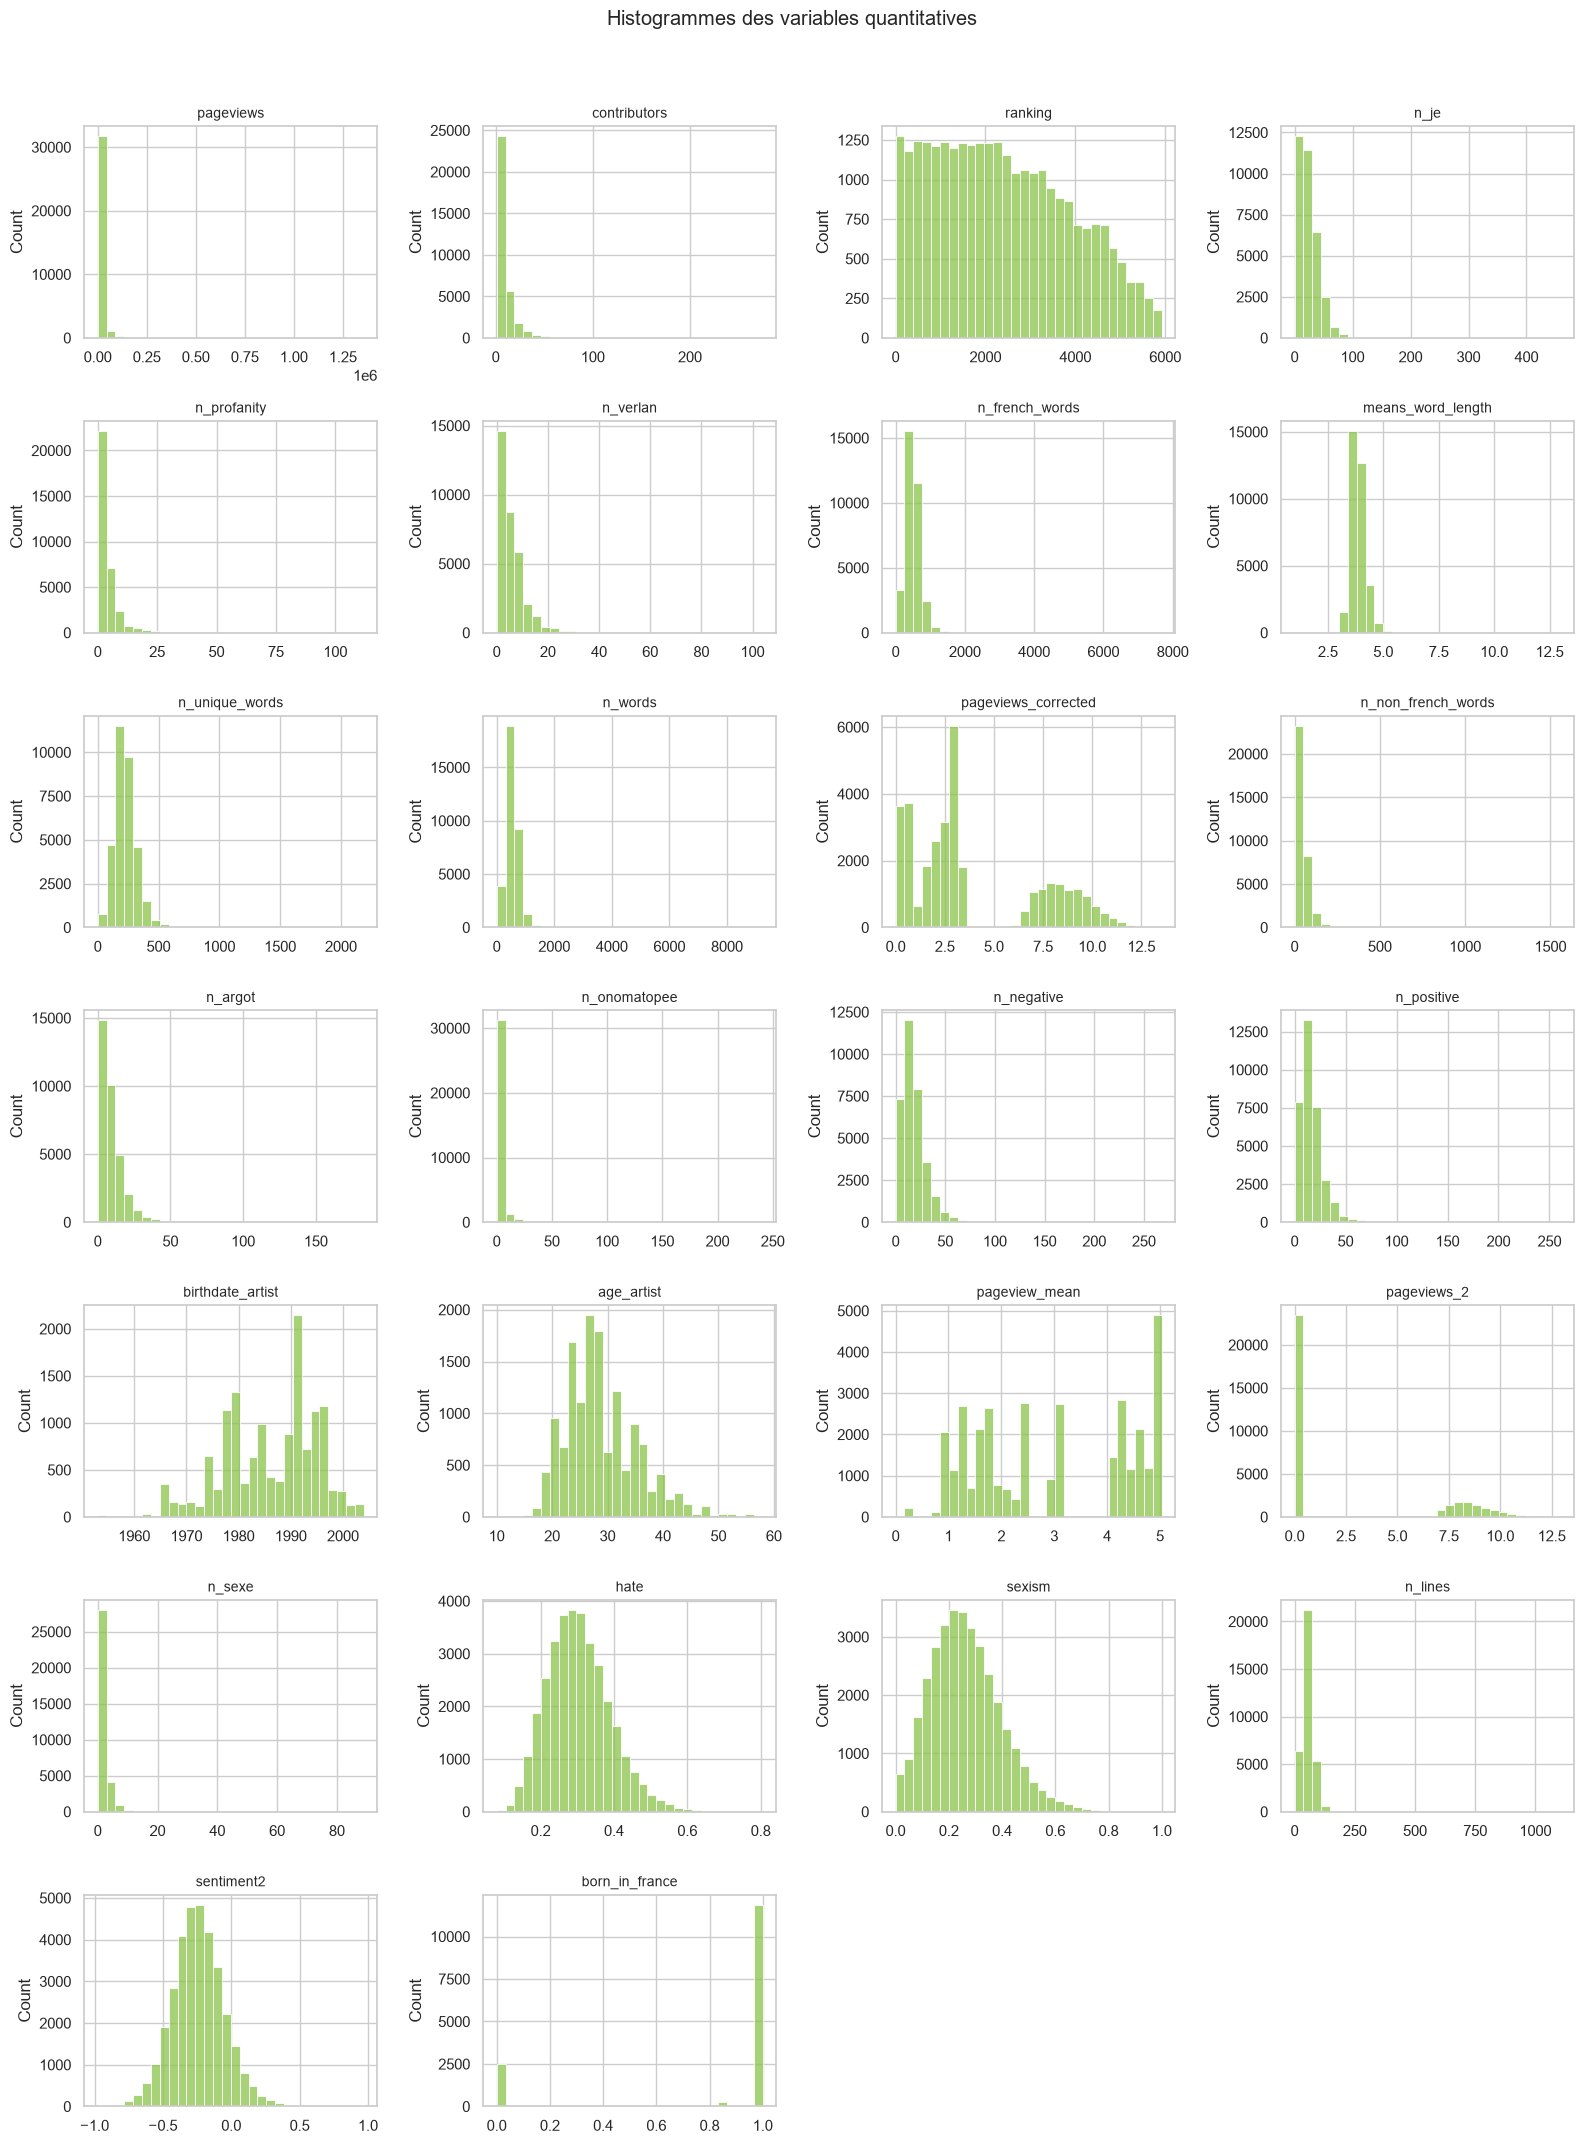

In [7]:
n_cols = 4
n_rows = int(np.ceil(len(numeric_cols) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3 * n_rows))
axes = axes.flatten()

for ax, col in zip(axes, numeric_cols):
    sns.histplot(df_analysis[col].dropna(), bins=30, ax=ax, color="#8bc34a")
    ax.set_title(col, fontsize=10)
    ax.set_xlabel("")

for ax in axes[len(numeric_cols):]:
    ax.axis("off")

fig.suptitle("Histogrammes des variables quantitatives", y=1.02)
fig.tight_layout()
fig.savefig(IMAGES_DIR / "05_1_histogrammes.png", bbox_inches="tight")
plt.show()

### 5.2 Courbes de densité

Estimation par noyau (KDE) de la densité de chaque variable, complémentaire aux histogrammes pour apprécier la forme (asymétrie, multimodalité).

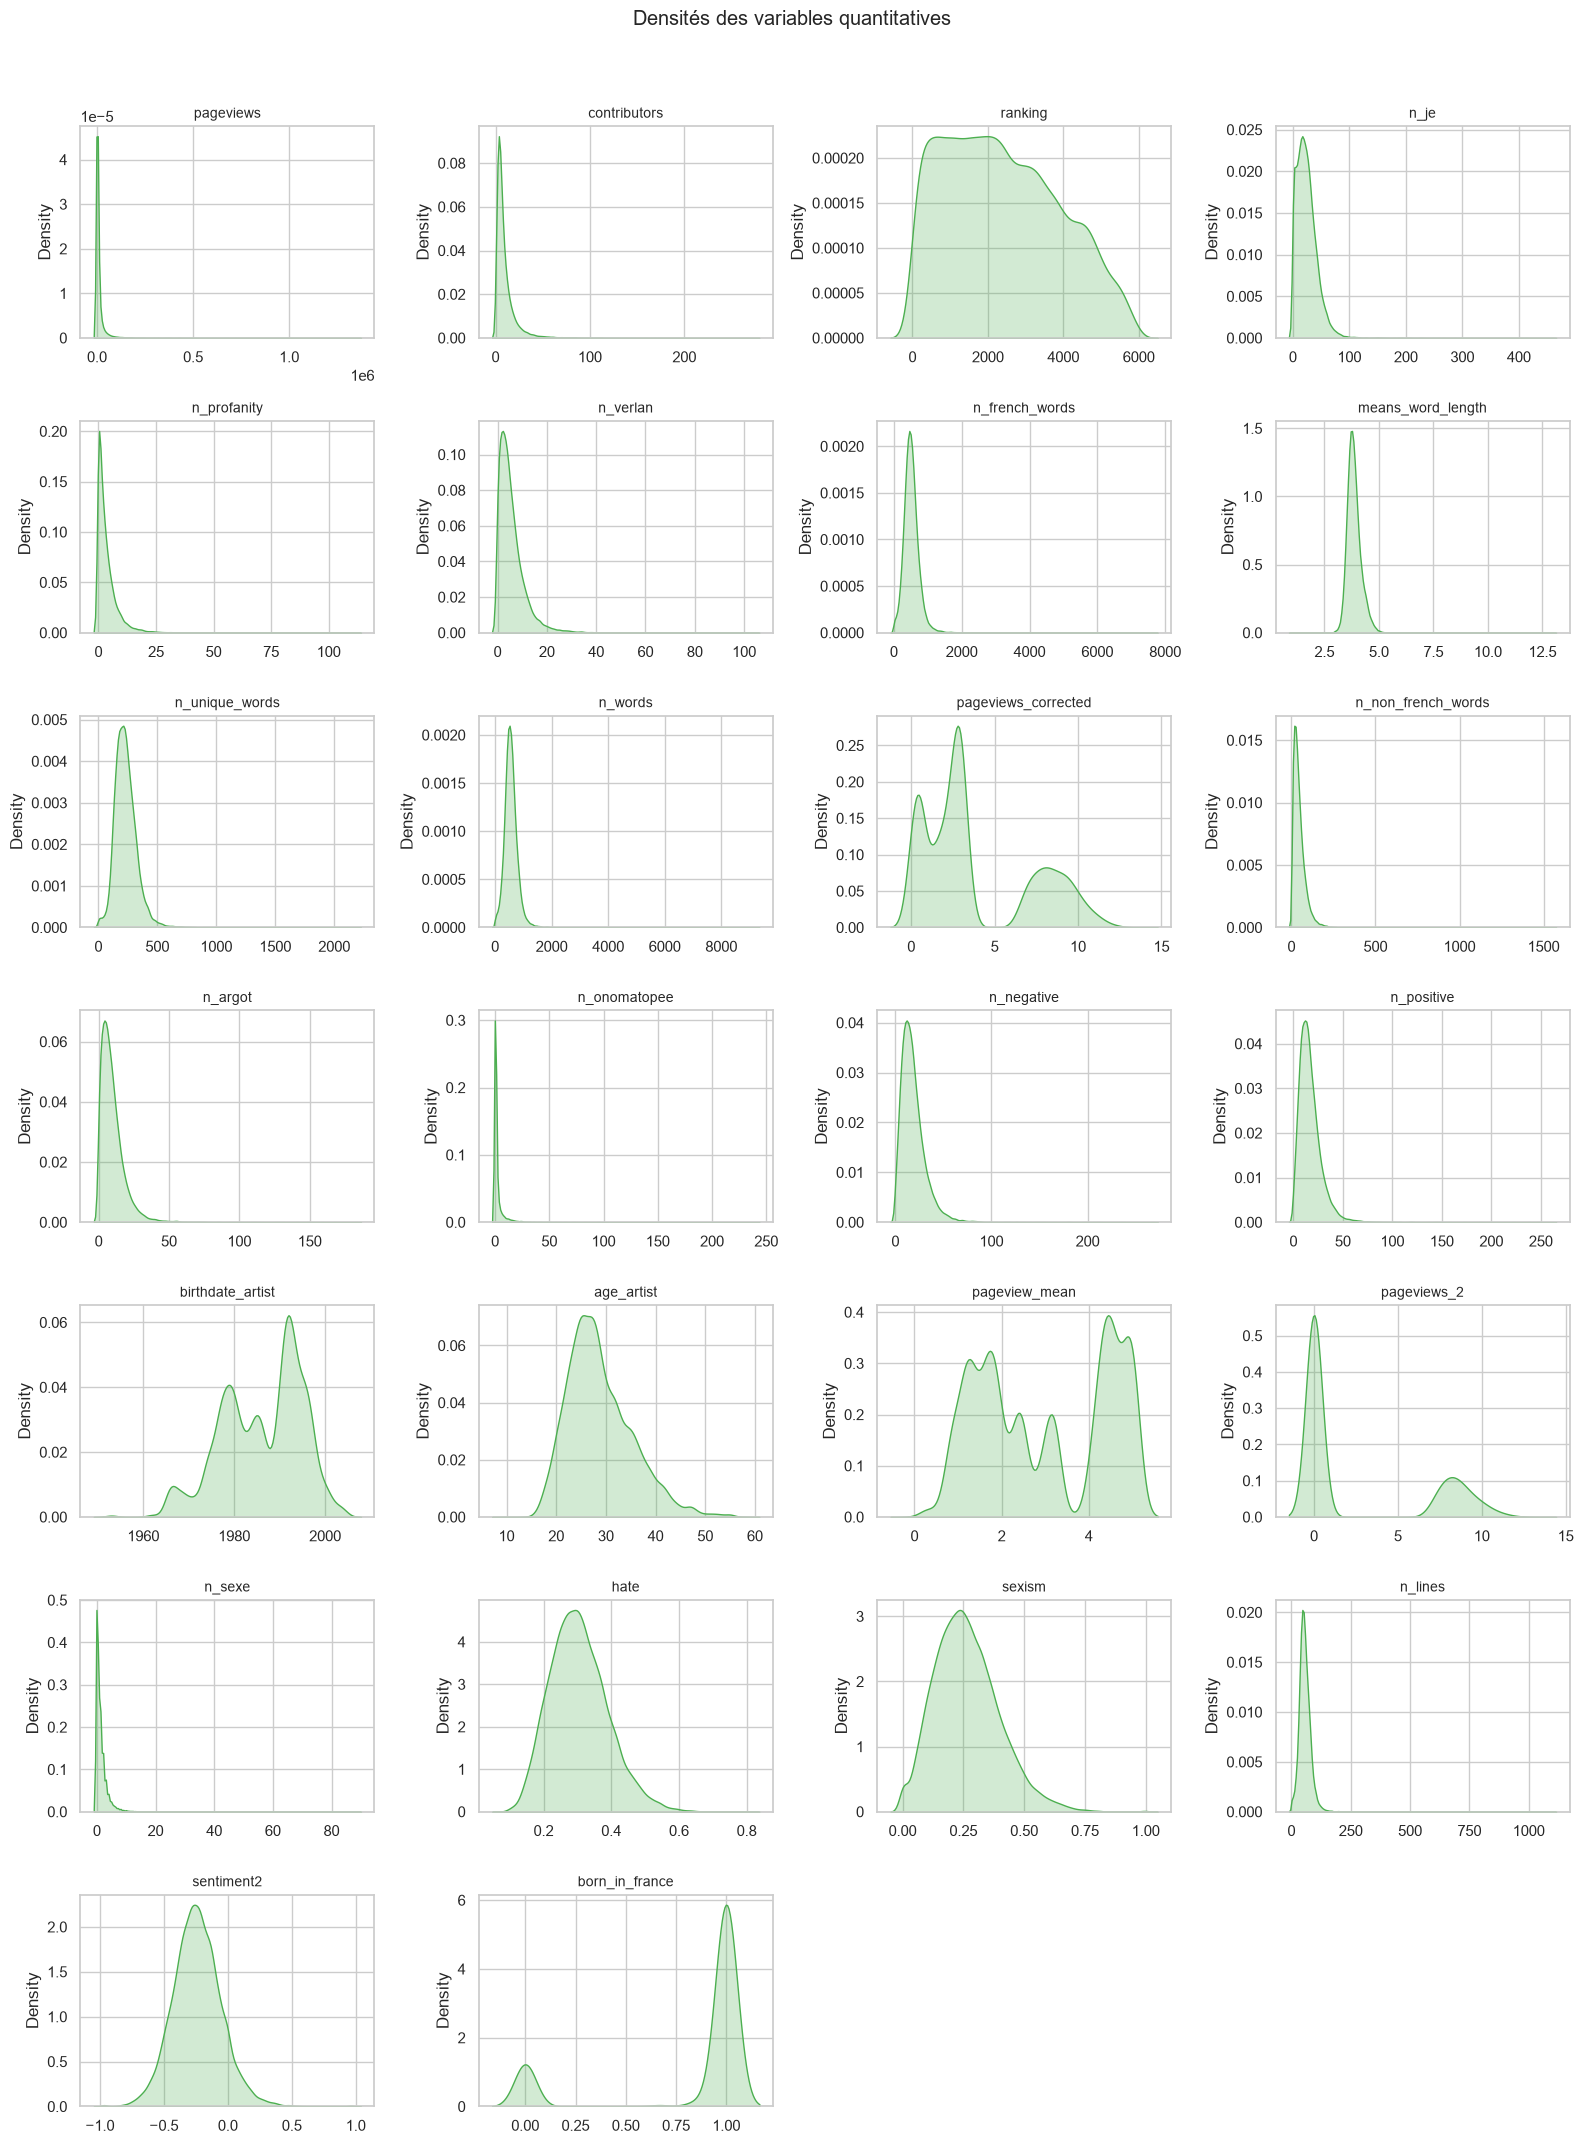

In [8]:
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3 * n_rows))
axes = axes.flatten()

for ax, col in zip(axes, numeric_cols):
    sns.kdeplot(df_analysis[col].dropna(), ax=ax, fill=True, color="#4caf50")
    ax.set_title(col, fontsize=10)
    ax.set_xlabel("")

for ax in axes[len(numeric_cols):]:
    ax.axis("off")

fig.suptitle("Densités des variables quantitatives", y=1.02)
fig.tight_layout()
fig.savefig(IMAGES_DIR / "05_2_densites.png", bbox_inches="tight")
plt.show()

### 5.3 Boxplots globaux

Les variables ayant des échelles très différentes, on les standardise (z-score) pour les comparer sur un même graphique et repérer dispersion et valeurs extrêmes.

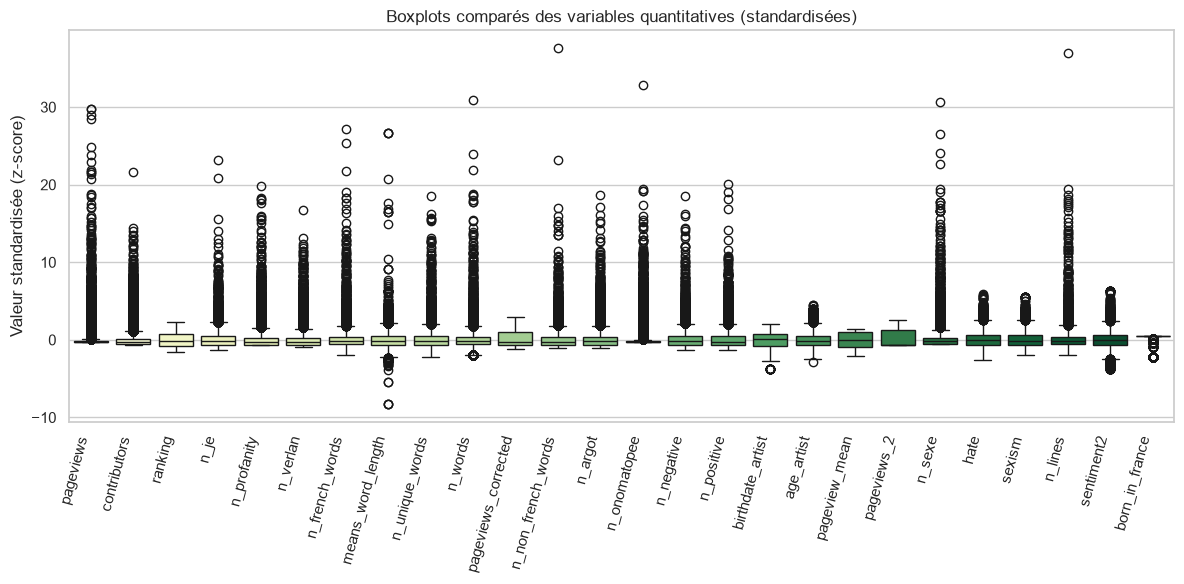

In [9]:
df_zscore = df_analysis[numeric_cols].apply(lambda s: (s - s.mean()) / s.std())

fig, ax = plt.subplots(figsize=(12, 6))
sns.boxplot(data=df_zscore, ax=ax, palette="YlGn")
ax.set_ylabel("Valeur standardisée (z-score)")
ax.set_title("Boxplots comparés des variables quantitatives (standardisées)")
plt.xticks(rotation=75, ha="right")
plt.tight_layout()
fig.savefig(IMAGES_DIR / "05_3_boxplots_globaux.png", bbox_inches="tight")
plt.show()

## 6. Distributions par année (facettes / sous-échantillons annuels)

Pour ne pas surcharger les graphiques, on se concentre sur quelques variables clés représentatives (longueur des textes, richesse lexicale, popularité, tonalité) afin de comparer la forme de leur distribution au fil des années.

### 6.1 Boxplots par année

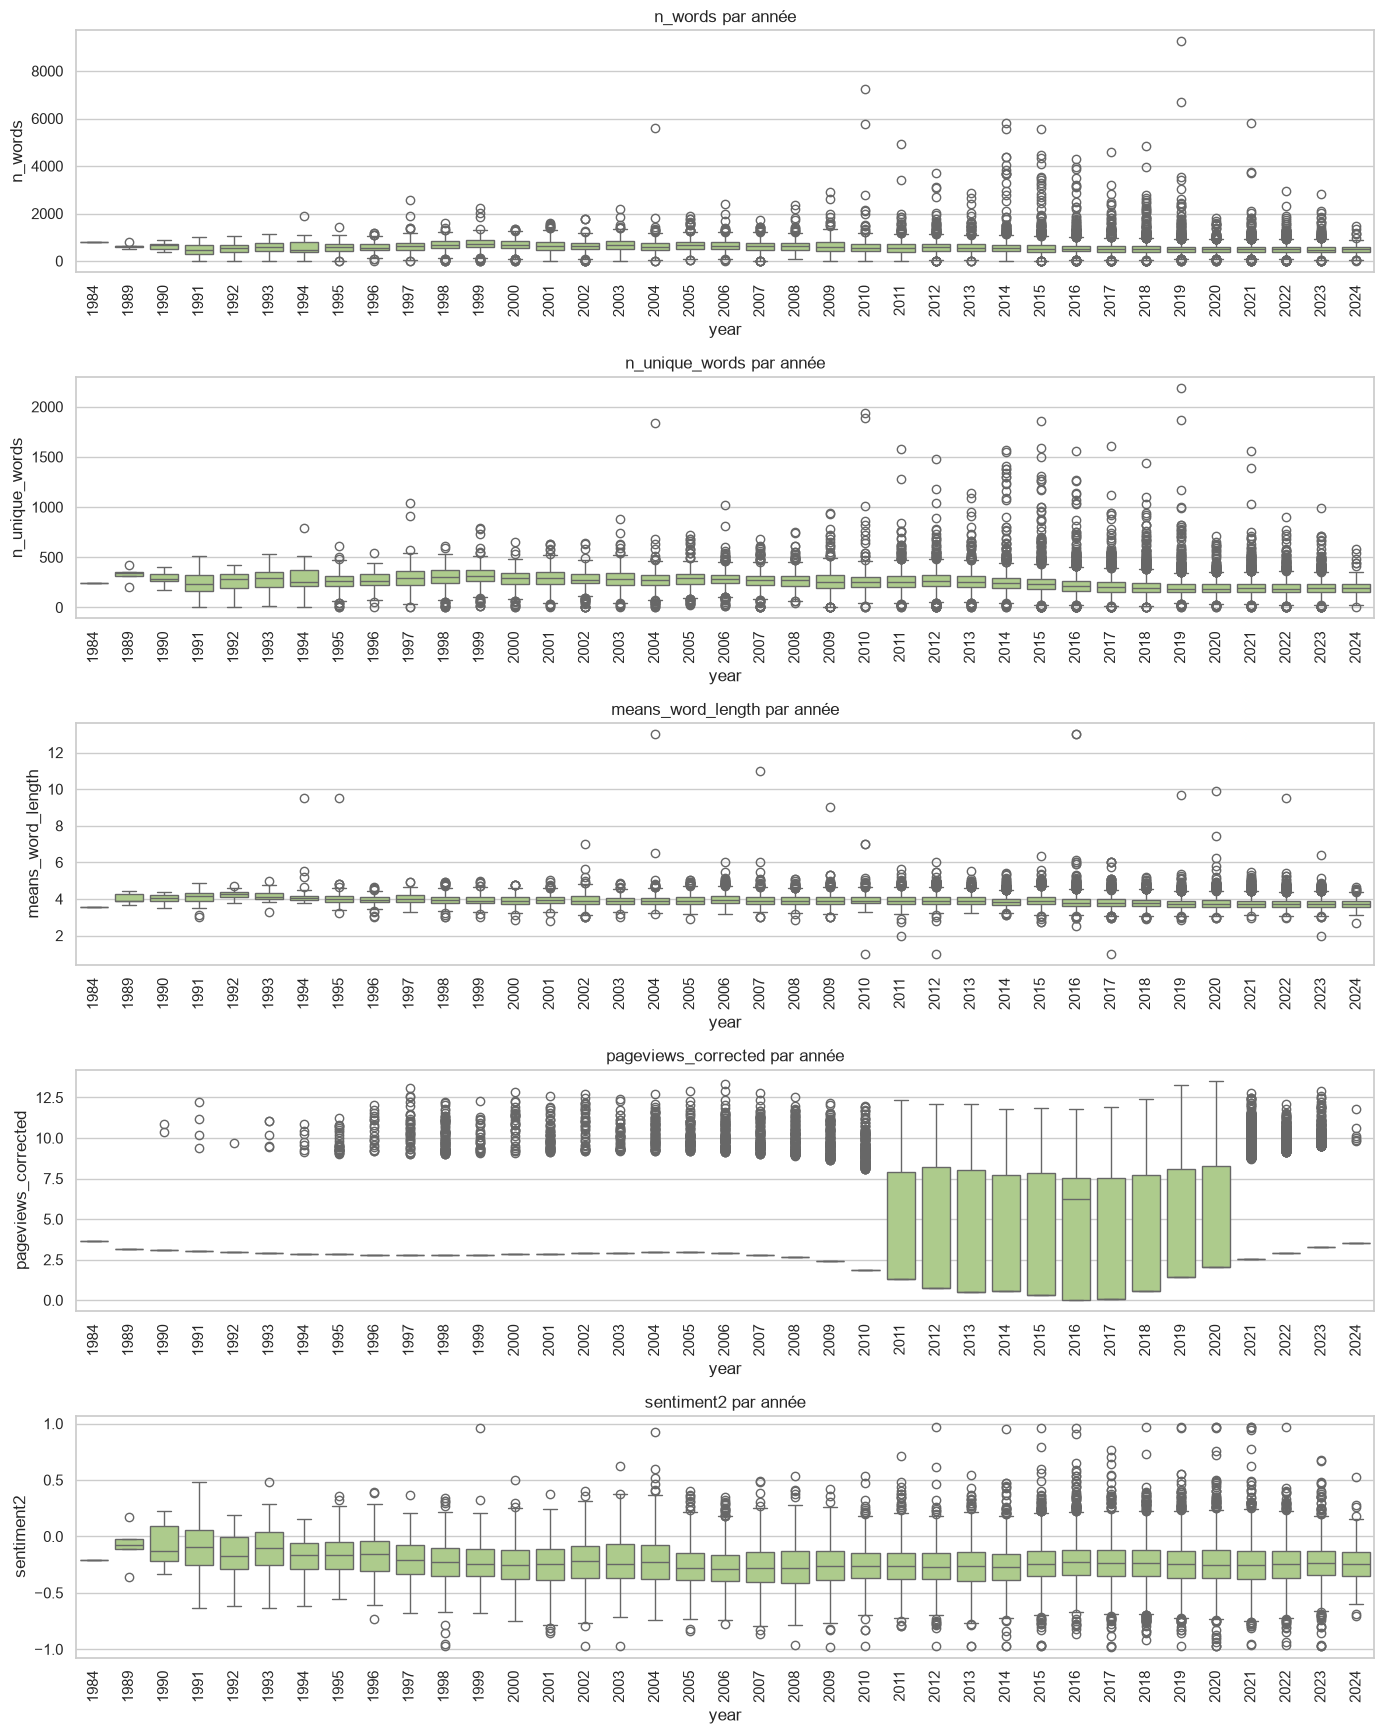

In [10]:
key_vars = ["n_words", "n_unique_words", "means_word_length", "pageviews_corrected", "sentiment2"]
key_vars = [v for v in key_vars if v in numeric_cols]

fig, axes = plt.subplots(len(key_vars), 1, figsize=(14, 3.5 * len(key_vars)))

for ax, col in zip(axes, key_vars):
    sns.boxplot(data=df_analysis, x="year", y=col, ax=ax, color="#aed581")
    ax.set_title(f"{col} par année")
    ax.tick_params(axis="x", rotation=90)

fig.tight_layout()
fig.savefig(IMAGES_DIR / "06_1_boxplots_par_annee.png", bbox_inches="tight")
plt.show()

### 6.2 Facettes d'histogrammes par décennie

Pour comparer la forme des distributions sur des sous-échantillons plus lisibles, on regroupe les années par décennie et on trace un histogramme par variable clé et par décennie.

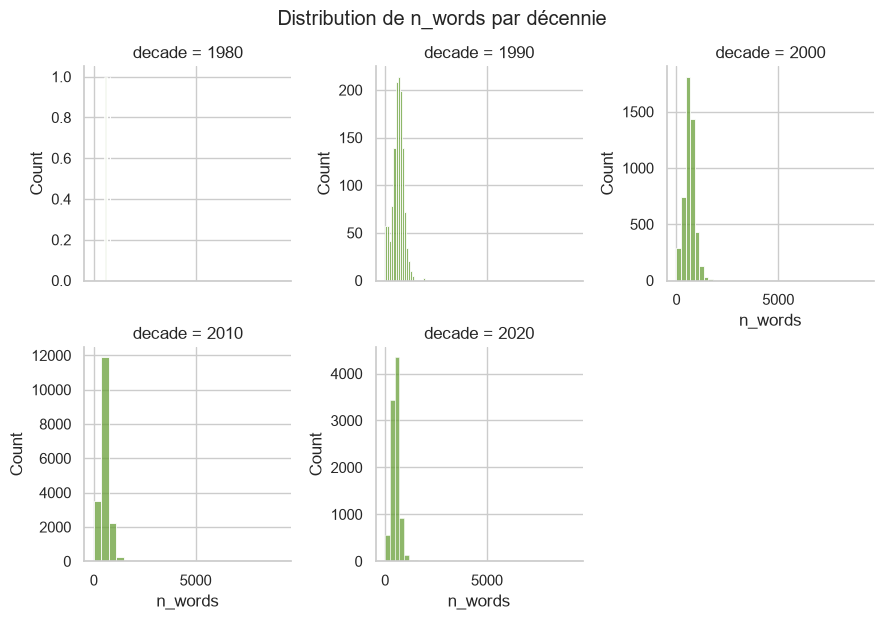

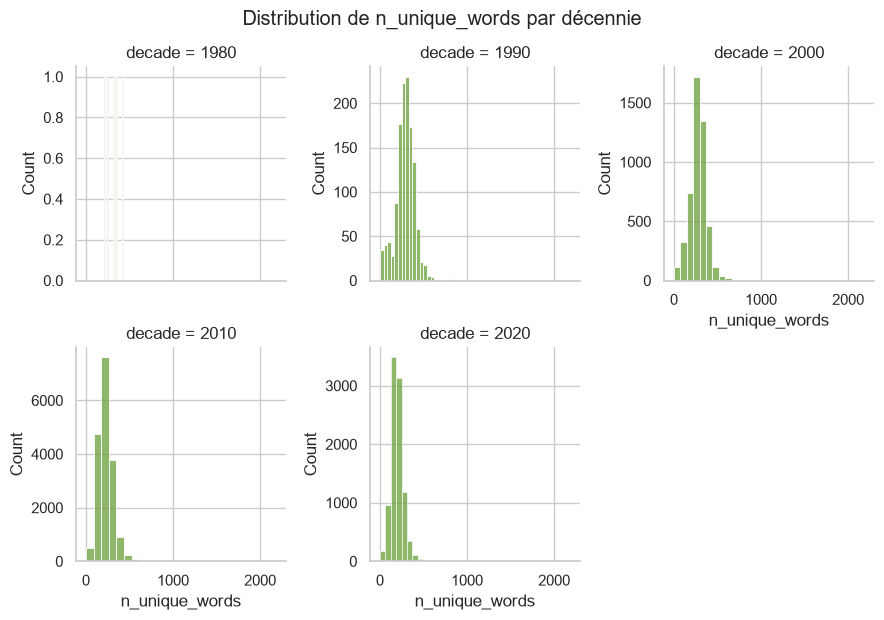

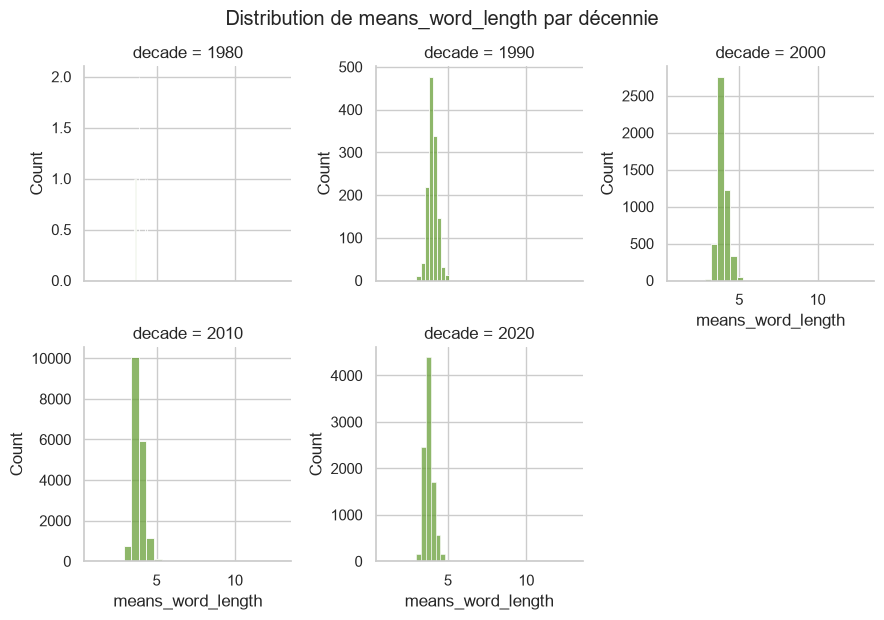

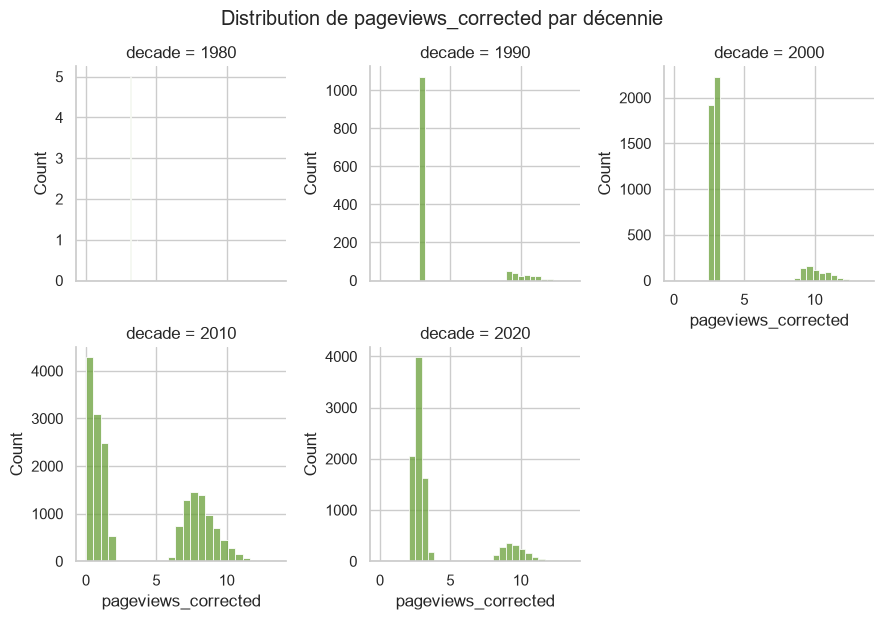

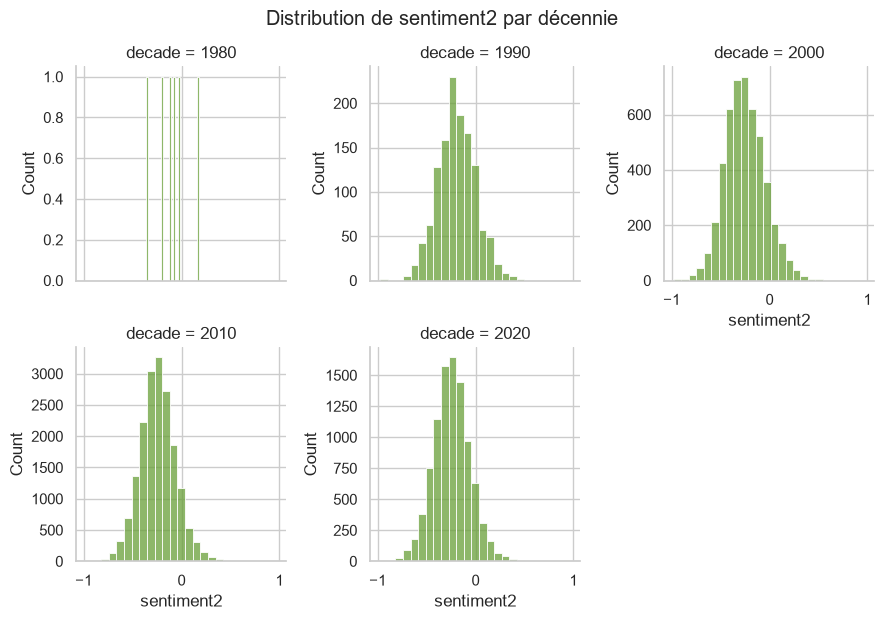

In [11]:
df_analysis["decade"] = (df_analysis["year"] // 10) * 10

for col in key_vars:
    g = sns.FacetGrid(df_analysis, col="decade", col_wrap=3, height=3, sharex=True, sharey=False)
    g.map(sns.histplot, col, bins=25, color="#689f38")
    g.figure.suptitle(f"Distribution de {col} par décennie", y=1.03)
    g.figure.savefig(IMAGES_DIR / f"06_2_facettes_{col}.png", bbox_inches="tight")
    plt.show()

## 7. Évolution des moyennes annuelles par variable

### 7.1 Agrégation par année

On calcule la moyenne annuelle de chaque variable quantitative.

In [12]:
annual_means = df_analysis.groupby("year")[numeric_cols].mean()
display(annual_means.head())

,pageviews,contributors,ranking,n_je,n_profanity,n_verlan,n_french_words,means_word_length,n_unique_words,n_words,pageviews_corrected,n_non_french_words,n_argot,n_onomatopee,n_negative,n_positive,birthdate_artist,age_artist,pageview_mean,pageviews_2,n_sexe,hate,sexism,n_lines,sentiment2,born_in_france
year,,,,,,,,,,,,,,,,,,,,,,,,,,
1984,0.00,9.00,"3,466.00",20.00,1.00,5.00,773.00,3.54,246.00,813.00,3.64,40.00,8.00,0.00,19.00,29.00,NaN,NaN,0.00,NaN,1.00,0.22,0.11,87.00,-0.21,NaN
1989,0.00,4.00,"1,771.80",15.40,2.20,3.80,589.20,4.02,328.80,631.00,3.16,41.80,8.00,0.00,16.80,18.20,"1,966.00",23.00,0.00,NaN,0.40,0.30,0.18,78.80,-0.08,0.86
1990,"2,157.22",5.67,"1,755.76",15.33,0.72,3.94,620.17,4.02,293.33,636.33,3.92,16.17,4.56,0.56,21.83,26.00,"1,966.60",23.40,1.09,1.08,1.17,0.24,0.13,76.11,-0.08,0.43
1991,"2,640.47",6.44,"2,321.64",10.03,1.12,2.31,436.93,4.10,233.15,459.68,3.53,22.75,5.15,0.32,14.59,16.12,"1,967.00",24.00,0.68,0.71,0.86,0.26,0.12,52.86,-0.09,0.51
1992,312.63,5.04,"2,297.60",12.48,1.96,3.04,521.85,4.25,262.30,545.26,3.20,23.41,5.63,0.15,15.41,17.22,"1,971.33",20.67,0.33,0.38,1.22,0.26,0.14,58.33,-0.16,0.97


### 7.2 Courbes temporelles par variable

Un graphique par variable, avec l'année en abscisse et la moyenne annuelle en ordonnée.

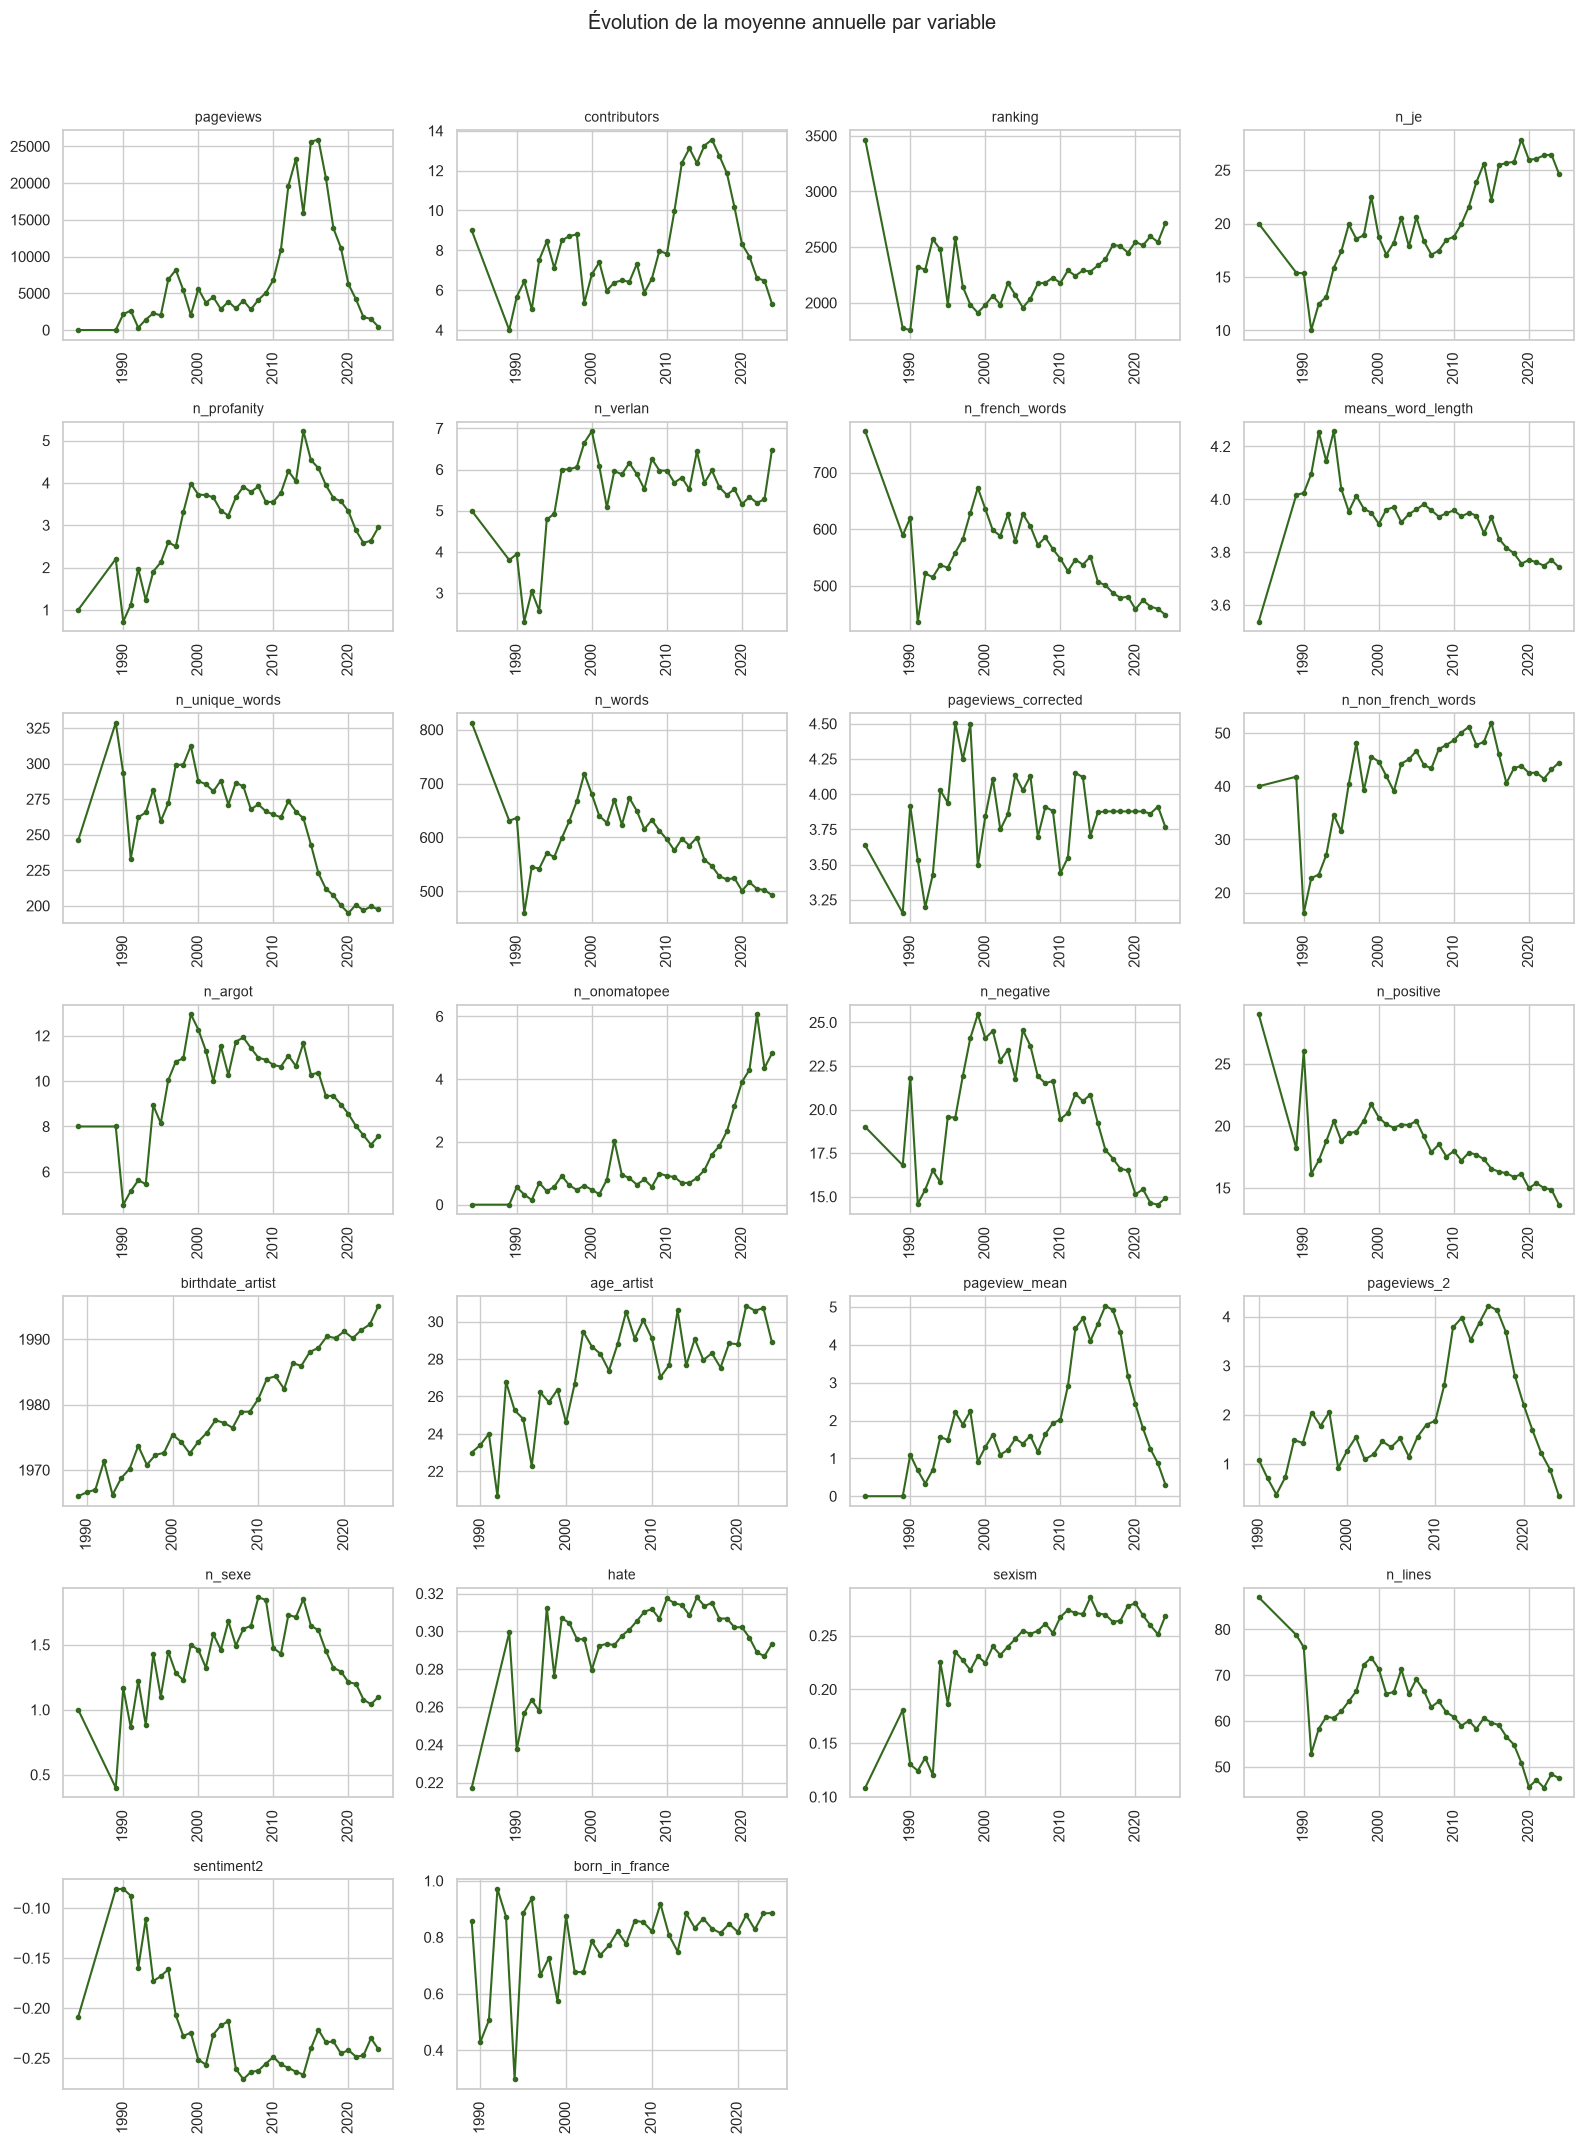

In [13]:
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3 * n_rows))
axes = axes.flatten()

for ax, col in zip(axes, numeric_cols):
    ax.plot(annual_means.index, annual_means[col], color="#33691e", marker="o", markersize=3)
    ax.set_title(col, fontsize=10)
    ax.tick_params(axis="x", rotation=90)

for ax in axes[len(numeric_cols):]:
    ax.axis("off")

fig.suptitle("Évolution de la moyenne annuelle par variable", y=1.02)
fig.tight_layout()
fig.savefig(IMAGES_DIR / "07_2_moyennes_annuelles.png", bbox_inches="tight")
plt.show()

## 8. Visualisations comparatives des tendances (multi-courbes, lissage)

### 8.1 Moyennes standardisées sur un même graphique

Les moyennes annuelles sont standardisées (z-score calculé sur la série de moyennes annuelles) afin de comparer les tendances de variables à échelles différentes sur un même graphique. On se limite aux variables clés pour la lisibilité.

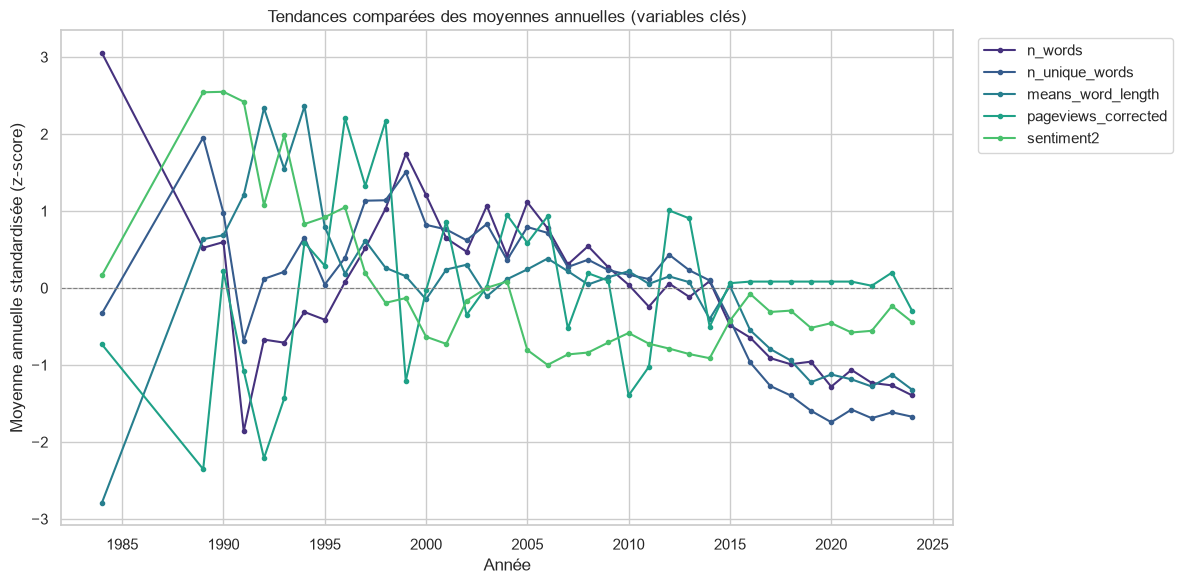

In [14]:
annual_means_z = annual_means.apply(lambda s: (s - s.mean()) / s.std())

fig, ax = plt.subplots(figsize=(12, 6))
for col in key_vars:
    ax.plot(annual_means_z.index, annual_means_z[col], marker="o", markersize=3, label=col)

ax.axhline(0, color="grey", linestyle="--", linewidth=0.8)
ax.set_xlabel("Année")
ax.set_ylabel("Moyenne annuelle standardisée (z-score)")
ax.set_title("Tendances comparées des moyennes annuelles (variables clés)")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
fig.savefig(IMAGES_DIR / "08_1_tendances_standardisees.png", bbox_inches="tight")
plt.show()

### 8.2 Lissage par moyenne mobile

Une moyenne mobile (fenêtre de 3 ans) est appliquée aux séries standardisées pour atténuer le bruit d'une année sur l'autre et mieux dégager les tendances de fond.

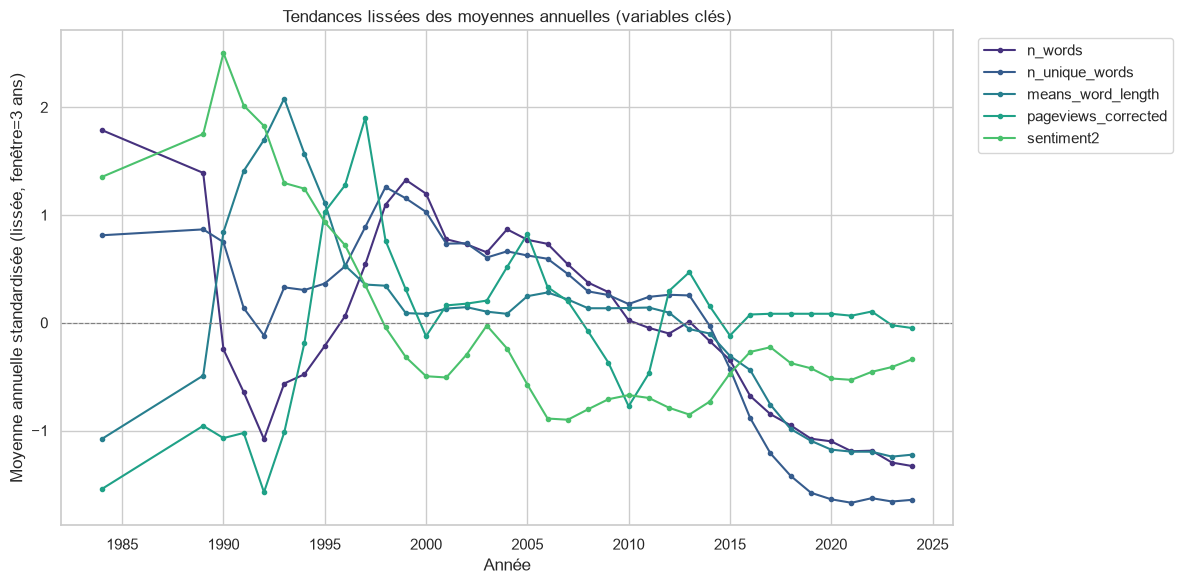

In [15]:
ROLLING_WINDOW = 3
annual_means_smoothed = annual_means_z[key_vars].rolling(window=ROLLING_WINDOW, center=True, min_periods=1).mean()

fig, ax = plt.subplots(figsize=(12, 6))
for col in key_vars:
    ax.plot(annual_means_smoothed.index, annual_means_smoothed[col], marker="o", markersize=3, label=col)

ax.axhline(0, color="grey", linestyle="--", linewidth=0.8)
ax.set_xlabel("Année")
ax.set_ylabel(f"Moyenne annuelle standardisée (lissée, fenêtre={ROLLING_WINDOW} ans)")
ax.set_title("Tendances lissées des moyennes annuelles (variables clés)")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
fig.savefig(IMAGES_DIR / "08_2_tendances_lissees.png", bbox_inches="tight")
plt.show()

## 9. Synthèse tabulaire exportable (moyennes annuelles et dispersion)

### 9.1 Table finale par année

Pour chaque variable quantitative et chaque année, on rassemble la moyenne, la médiane et l'écart-type dans une table à colonnes multi-niveaux (variable, statistique).

In [16]:
annual_summary = df_analysis.groupby("year")[numeric_cols].agg(["mean", "median", "std"])
annual_summary.columns = [f"{var}_{stat}" for var, stat in annual_summary.columns]
display(annual_summary.head())

,pageviews_mean,pageviews_median,pageviews_std,contributors_mean,contributors_median,contributors_std,ranking_mean,ranking_median,ranking_std,n_je_mean,n_je_median,n_je_std,n_profanity_mean,n_profanity_median,n_profanity_std,n_verlan_mean,n_verlan_median,n_verlan_std,n_french_words_mean,n_french_words_median,n_french_words_std,means_word_length_mean,means_word_length_median,means_word_length_std,n_unique_words_mean,n_unique_words_median,n_unique_words_std,n_words_mean,n_words_median,n_words_std,pageviews_corrected_mean,pageviews_corrected_median,pageviews_corrected_std,n_non_french_words_mean,n_non_french_words_median,n_non_french_words_std,n_argot_mean,n_argot_median,n_argot_std,n_onomatopee_mean,n_onomatopee_median,n_onomatopee_std,n_negative_mean,n_negative_median,n_negative_std,n_positive_mean,n_positive_median,n_positive_std,birthdate_artist_mean,birthdate_artist_median,birthdate_artist_std,age_artist_mean,age_artist_median,age_artist_std,pageview_mean_mean,pageview_mean_median,pageview_mean_std,pageviews_2_mean,pageviews_2_median,pageviews_2_std,n_sexe_mean,n_sexe_median,n_sexe_std,hate_mean,hate_median,hate_std,sexism_mean,sexism_median,sexism_std,n_lines_mean,n_lines_median,n_lines_std,sentiment2_mean,sentiment2_median,sentiment2_std,born_in_france_mean,born_in_france_median,born_in_france_std
year,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1984,0.00,0.00,NaN,9.00,9.00,NaN,"3,466.00","3,466.00",NaN,20.00,20.00,NaN,1.00,1.00,NaN,5.00,5.00,NaN,773.00,773.00,NaN,3.54,3.54,NaN,246.00,246.00,NaN,813.00,813.00,NaN,3.64,3.64,NaN,40.00,40.00,NaN,8.00,8.00,NaN,0.00,0.00,NaN,19.00,19.00,NaN,29.00,29.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.00,0.00,NaN,NaN,NaN,NaN,1.00,1.00,NaN,0.22,0.22,NaN,0.11,0.11,NaN,87.00,87.00,NaN,-0.21,-0.21,NaN,NaN,NaN,NaN
1989,0.00,0.00,0.00,4.00,4.00,2.55,"1,771.80","1,860.00","1,133.10",15.40,10.00,10.14,2.20,1.00,2.77,3.80,3.00,2.77,589.20,589.00,88.47,4.02,3.89,0.30,328.80,339.00,79.18,631.00,637.00,104.62,3.16,3.16,0.00,41.80,48.00,23.75,8.00,4.00,9.72,0.00,0.00,0.00,16.80,12.00,9.83,18.20,18.00,5.93,"1,966.00","1,966.00",0.00,23.00,23.00,0.00,0.00,0.00,0.00,NaN,NaN,NaN,0.40,0.00,0.55,0.30,0.29,0.08,0.18,0.15,0.09,78.80,81.00,10.06,-0.08,-0.08,0.19,0.86,0.86,0.00
1990,"2,157.22",0.00,"6,470.91",5.67,4.50,4.27,"1,755.76","1,204.00","1,721.78",15.33,12.00,10.91,0.72,1.00,0.83,3.94,2.00,4.36,620.17,644.50,138.05,4.02,4.05,0.26,293.33,281.00,56.77,636.33,664.00,137.37,3.92,3.08,2.44,16.17,9.00,12.33,4.56,4.00,3.79,0.56,0.00,0.78,21.83,19.50,11.67,26.00,24.00,10.56,"1,966.60","1,966.00",1.34,23.40,24.00,1.34,1.09,1.09,0.00,1.08,0.00,3.16,1.17,1.00,1.50,0.24,0.24,0.04,0.13,0.13,0.06,76.11,80.00,13.64,-0.08,-0.13,0.17,0.43,0.43,0.61
1991,"2,640.47",0.00,"13,892.04",6.44,5.00,5.84,"2,321.64","2,112.00","1,624.40",10.03,8.00,8.71,1.12,0.00,1.92,2.31,1.00,2.97,436.93,454.00,256.93,4.10,4.14,0.34,233.15,236.00,129.61,459.68,473.00,266.45,3.53,3.01,1.98,22.75,17.00,25.74,5.15,4.00,5.62,0.32,0.00,0.63,14.59,12.00,12.68,16.12,14.00,12.80,"1,967.00","1,966.00",1.43,24.00,25.00,1.43,0.68,0.68,0.00,0.71,0.00,2.66,0.86,1.00,1.01,0.26,0.25,0.09,0.12,0.10,0.11,52.86,54.00,30.02,-0.09,-0.09,0.21,0.51,0.86,0.43
1992,312.63,0.00,"1,624.47",5.04,5.00,2.46,"2,297.60","2,027.00","1,584.01",12.48,11.00,10.42,1.96,1.00,2.38,3.04,2.00,3.29,521.85,561.00,218.92,4.25,4.25,0.20,262.30,286.00,96.30,545.26,565.00,227.53,3.20,2.95,1.30,23.41,18.00,20.40,5.63,3.00,7.15,0.15,0.00,0.46,15.41,15.00,9.25,17.22,16.00,11.88,"1,971.33","1,966.00",9.24,20.67,26.00,9.24,0.33,0.33,0.00,0.38,0.00,1.95,1.22,1.00,1.37,0.26,0.25,0.08,0.14,0.10,0.13,58.33,60.00,23.08,-0.16,-0.17,0.20,0.97,1.00,0.06


### 9.2 Export CSV

La table de synthèse est exportée pour être réutilisée directement dans les notebooks suivants du projet, sans avoir à recharger et retraiter le fichier brut.

In [17]:
output_path = RESULT_DIR / "annual_summary_quantitative_variables.csv"
annual_summary.to_csv(output_path)
print(f"Table exportée vers : {output_path}")

Table exportée vers : result\annual_summary_quantitative_variables.csv
